# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

## Sobre este Trabajo Práctico

El objetivo de este trabajo es que puedas aplicar los conceptos de regresión sobre un dataset real, tomando decisiones propias en cada etapa: qué atributos usar, qué modelo elegir y cómo interpretar los resultados.

No se trata solo de ejecutar el código: se espera que puedas **justificar tus elecciones**, **interpretar los errores obtenidos** y **explicar qué está pasando** en cada experimento.

Al finalizar, deberías poder responder: ¿qué modelo elegirías para este problema y por qué? ¿Cómo reconocés underfitting y overfitting en tus resultados?



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:

#print(california['DESCR'])  # descripción del dataset
california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [6]:
from sklearn.model_selection import train_test_split
X, y = california['data'], california['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [7]:
y.shape

(20640,)

In [8]:
y_test.shape

(4128,)

## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

### Respuestas

**1. ¿De qué se trata el conjunto de datos?**
Son datos del censo de EE.UU. de **1990** agregados por *block group* (la unidad geográfica más chica del censo, ~600–3000 habitantes) en el estado de California. Cada fila describe un block group con características socioeconómicas y de vivienda promedio.

**2. ¿Cuál es la variable objetivo? ¿Qué significa?**
El target es el **valor medio de las viviendas** del block group, expresado en **cientos de miles de dólares** (un `1.0` = USD 100.000). Está **truncado en 5.0** (los valores ≥ \$500k se cortan ahí), lo cual ya anticipa un problema: el modelo nunca va a poder predecir bien las zonas más caras.

**3. ¿Qué atributos hay disponibles?**
- `MedInc`: ingreso mediano del block group.
- `HouseAge`: antigüedad mediana de las viviendas.
- `AveRooms` / `AveBedrms`: promedio de habitaciones / dormitorios por hogar.
- `Population`: población del block group.
- `AveOccup`: ocupantes promedio por hogar.
- `Latitude` / `Longitude`: coordenadas geográficas.

**4. ¿Qué atributos imagino más determinantes?**
Mi hipótesis *a priori*: `MedInc` (zonas ricas → casas caras) y la **ubicación** (`Latitude`/`Longitude`: costa y grandes ciudades valen más). `AveRooms` debería aportar algo (tamaño), y `HouseAge` poco y de forma no lineal. La voy a contrastar contra los datos en el Ej2.

**5. Problemas, sesgos y dilemas éticos.**
- **Datos viejos (1990):** un modelo entrenado acá no sirve para precios actuales; la distribución cambió.
- **Truncamiento del target en 5.0:** introduce un techo artificial y degrada la predicción en el rango alto.
- **Outliers en `AveRooms`/`AveBedrms`:** la propia documentación avisa que toman valores enormes en block groups con pocos hogares (zonas vacacionales). Hay que vigilarlos o filtrarlos.
- **Sesgo socioeconómico / ético:** usar `MedInc` como predictor central puede **reforzar desigualdades** (redlining algorítmico). Si esto alimentara decisiones de crédito o seguros, perpetuaría la segregación. No es un dato neutro.

## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

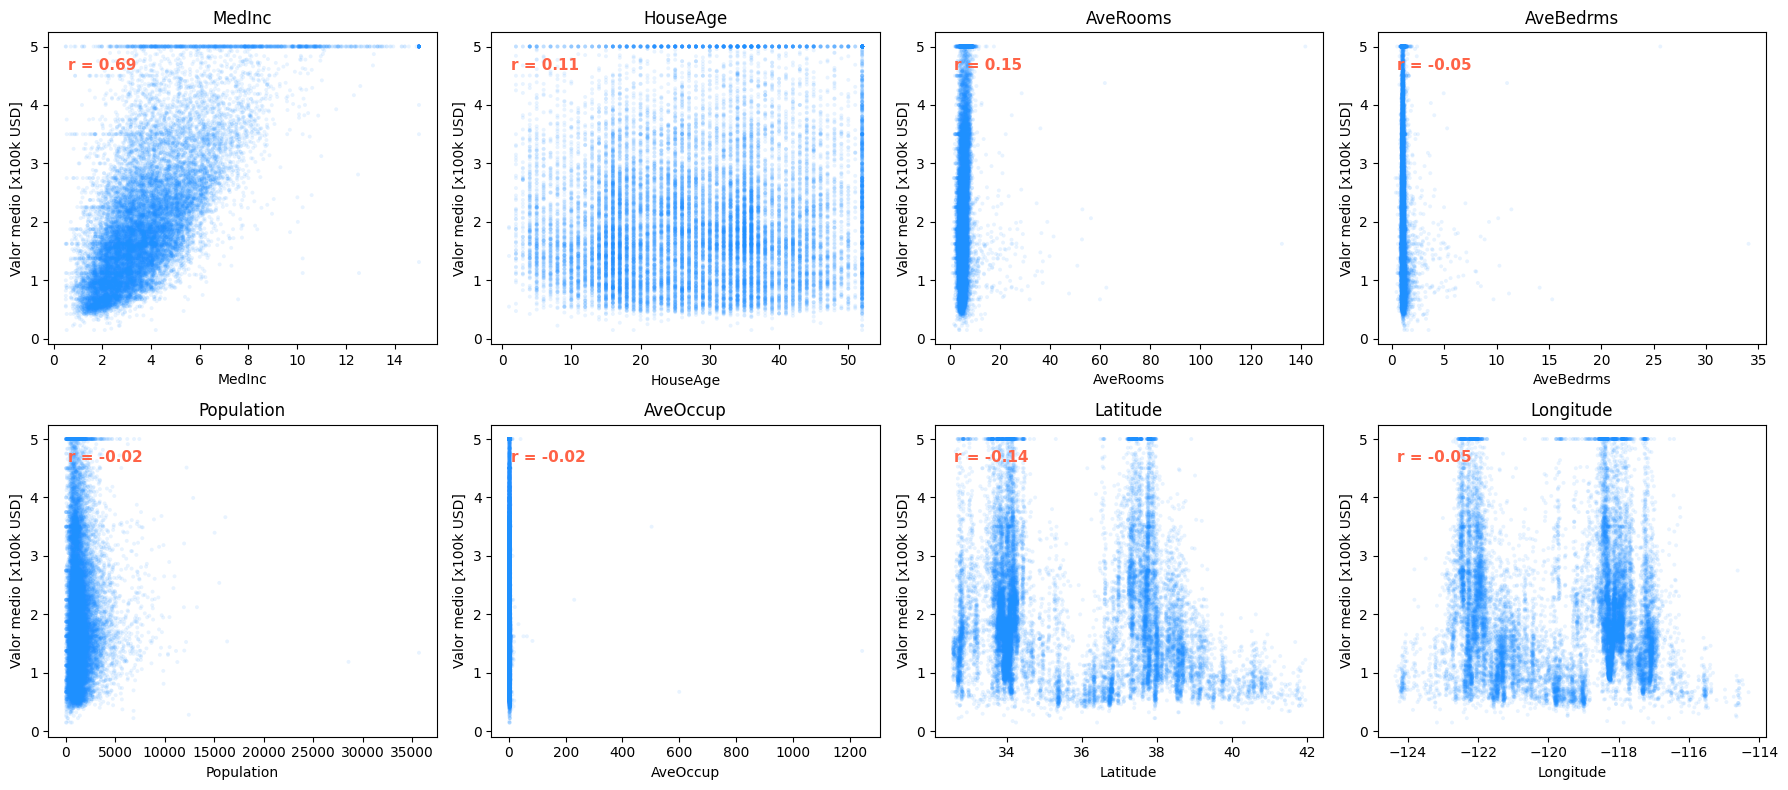

In [9]:
# 1. Una grafica por atributo vs. el target.
#    Anoto el coeficiente de correlacion de Pearson (r) en cada panel: respalda
#    numericamente la lectura "a ojo" y deja claro cuanto pesa cada atributo.
feature_names = california['feature_names']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, i in zip(axes.ravel(), range(len(feature_names))):
    ax.scatter(X[:, i], y, alpha=0.1, s=8, color="dodgerblue", edgecolor="none")
    r = np.corrcoef(X[:, i], y)[0, 1]
    ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.88), xycoords="axes fraction",
                fontsize=11, color="tomato", fontweight="bold")
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("Valor medio [x100k USD]")
    ax.set_title(feature_names[i])
plt.tight_layout()
plt.show()

In [10]:
# Apoyo cuantitativo a la inspeccion visual: correlacion (en valor absoluto) de cada feature con el target.
corr = pd.DataFrame(X, columns=feature_names).corrwith(pd.Series(y)).abs().sort_values(ascending=False)
print("Correlacion |Pearson| con el target:")
print(corr.round(3).to_string())

Correlacion |Pearson| con el target:
MedInc        0.688
AveRooms      0.152
Latitude      0.144
HouseAge      0.106
AveBedrms     0.047
Longitude     0.046
Population    0.025
AveOccup      0.024


### 2. Lectura de las gráficas

- **`MedInc`** es el único con una **relación lineal positiva clara y fuerte**: a más ingreso, más valor. Es el predictor individual más informativo (y la correlación numérica de arriba lo confirma, ~0.69).
- **`Latitude` / `Longitude`** no muestran una relación lineal simple, pero sí **patrones geográficos**: hay franjas de valores altos (costa) y bajas (interior). La info está, aunque un modelo lineal univariado no la captura bien.
- **`AveRooms`** tiene una correlación positiva **moderada** pero con mucha dispersión y outliers.
- **`HouseAge`** es difusa, sin tendencia lineal marcada.
- **`AveBedrms`, `Population`, `AveOccup`** se ven como nubes planas → poco informativas a ojo.

### 3. Ranking de importancia (inspección visual)

1. **`MedInc`** — el más informativo, lejos.
2. **`Latitude` + `Longitude`** — la ubicación; clave pero no lineal.
3. **`AveRooms`** — aporte moderado (tamaño de la vivienda).
4. **`HouseAge`** — aporte menor.

El resto (`AveBedrms`, `Population`, `AveOccup`) los considero poco relevantes para empezar. Este ranking es el que voy a usar para elegir atributos en los ejercicios siguientes.

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

In [11]:
# 1. Elijo el atributo mas informativo segun el Ej2: MedInc.
feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)

X_train_f = X_train[:, selector]
X_test_f  = X_test[:, selector]
X_train_f.shape, X_test_f.shape

((16512, 1), (4128, 1))

In [12]:
# Un vistazo rapido a los datos del atributo elegido.
print("primeros 5 valores de MedInc (train):", X_train_f[:5].ravel())

primeros 5 valores de MedInc (train): [4.2386 4.3898 3.9333 1.4653 3.1765]


In [13]:
# 2. Instanciar y entrenar la regresion lineal con UN solo atributo.
model = LinearRegression()
model.fit(X_train_f, y_train)
print(f"pendiente = {model.coef_[0]:.4f} | ordenada = {model.intercept_:.4f}")

pendiente = 0.4203 | ordenada = 0.4432


In [14]:
# 3. Predecir y evaluar con MSE en train y test.
y_pred_train = model.predict(X_train_f)
y_pred_test  = model.predict(X_test_f)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
print(f"MSE train: {mse_train:.4f} | MSE test: {mse_test:.4f}")
print(f"RMSE test: {np.sqrt(mse_test):.4f}  (~${np.sqrt(mse_test)*100:.0f}k de error tipico)")

MSE train: 0.6961 | MSE test: 0.7215
RMSE test: 0.8494  (~$85k de error tipico)


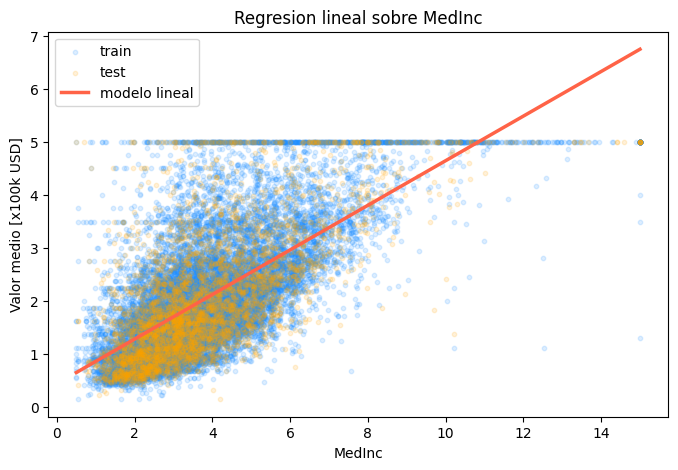

In [15]:
# 4. Graficar el modelo junto a los puntos de train y test.
x_start = min(np.min(X_train_f), np.min(X_test_f))
x_end   = max(np.max(X_train_f), np.max(X_test_f))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_f, y_train, alpha=0.15, s=10, color="dodgerblue", label="train")
plt.scatter(X_test_f,  y_test,  alpha=0.15, s=10, color="orange", label="test")
plt.plot(x, model.predict(x), color="tomato", lw=2.5, label="modelo lineal")
plt.xlabel(feature)
plt.ylabel("Valor medio [x100k USD]")
plt.title("Regresion lineal sobre MedInc")
plt.legend()
plt.show()

### 5. Interpretación

- **MSE train 0.6961 vs test 0.7215**: casi iguales → **no hay overfitting**. El modelo generaliza tan (mal) como entrena.
- El RMSE ≈ 0.85 → un error del orden de **~\$85.000** en unidades del target. *(Ojo: el RMSE no es el error absoluto promedio; penaliza más los errores grandes. Lo uso solo para tener intuición de magnitud; las comparaciones entre modelos las hago en MSE.)* Es un error grande para este problema: el modelo es **demasiado simple** (alto *bias*) → **underfitting**.
- En el gráfico se ve la **banda horizontal en y ≈ 5.0**: es el **truncamiento del target** (los valores ≥ \$500k se cortan ahí). La recta no puede ajustar esos puntos, lo que **limita la calidad del ajuste en el rango alto**.

> **Nota sobre el enunciado:** dice "se puede obtener un error en test menor a **50**" (y en Ej4 "<40, <35"). Verifiqué que con el `fetch_california_housing` actual esos números no encajan: el target vive en `[0.15, 5.0]` y un modelo razonable da MSE del orden de **0.3–0.7** (nuestro 0.72 es correcto). Son números **legacy**, de una versión del dataset con **otra escala**.
>
> *Matiz honesto (lo corregí tras revisión):* NO es que un MSE de 50 sea *matemáticamente imposible* — las **predicciones del modelo no están acotadas** a [0, 5] (de hecho en el Ej6, con grado 2, el MSE se dispara a 2.76). Lo correcto es decir que **para modelos razonables a esta escala** el error vive en décimas, no en decenas; por eso el "<50" delata otra escala, no un límite duro.

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [16]:
# 1. Regresion polinomial de varios grados sobre el MISMO atributo (MedInc).
#    Reconstruyo el slice aca para que la celda sea autocontenida (no depende del orden de ejecucion del Ej3).
feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)
X_train_f, X_test_f = X_train[:, selector], X_test[:, selector]

#    Pipeline: PolynomialFeatures -> StandardScaler (estabilidad numerica) -> LinearRegression.
grados = range(1, 11)
errores_train, errores_test = [], []

for d in grados:
    poly_model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    poly_model.fit(X_train_f, y_train)
    mtr = mean_squared_error(y_train, poly_model.predict(X_train_f))
    mte = mean_squared_error(y_test,  poly_model.predict(X_test_f))
    errores_train.append(mtr)
    errores_test.append(mte)
    print(f"grado {d:2d}: MSE train {mtr:.4f} | test {mte:.4f}")

grado  1: MSE train 0.6961 | test 0.7215


grado  2: MSE train 0.6895 | test 0.7174
grado  3: MSE train 0.6782 | test 0.7081
grado  4: MSE train 0.6781 | test 0.7080
grado  5: MSE train 0.6780 | test 0.7080
grado  6: MSE train 0.6761 | test 0.7068
grado  7: MSE train 0.6737 | test 0.7026
grado  8: MSE train 0.6736 | test 0.7021
grado  9: MSE train 0.6736 | test 0.7021
grado 10: MSE train 0.6735 | test 0.7021


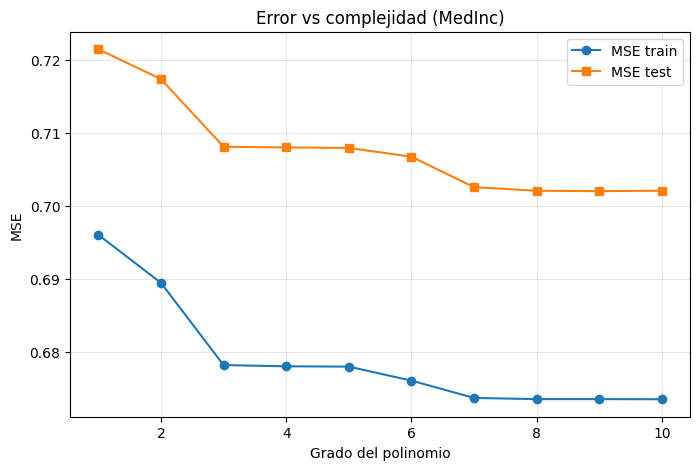

In [17]:
# 2. Curvas de error en funcion del grado del polinomio.
plt.figure(figsize=(8, 5))
plt.plot(list(grados), errores_train, "o-", label="MSE train")
plt.plot(list(grados), errores_test,  "s-", label="MSE test")
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE")
plt.title("Error vs complejidad (MedInc)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3. ¿Dónde empieza el sobreajuste?

Acá pasa algo que **vale la pena entender, no maquillar**: con **un solo atributo NO aparece overfitting** en el rango de grados 1–10. Train y test bajan **juntos** y se **estancan** (de 0.72 a ~0.70). La diferencia train–test se mantiene mínima.

¿Por qué? Porque el problema no es exceso de complejidad sino **falta de información**: `MedInc` solo no tiene señal suficiente, así que el modelo está dominado por **bias (underfitting)**, no por varianza. La clásica curva en U (test que vuelve a subir) **no se da** mientras tengamos un único feature pobre. El sobreajuste lo vamos a ver recién cuando metamos muchos features y grados altos (Ej6).

> **Respondiendo a la consigna:** en el rango de grados probado (1–10) **no hay un punto donde empiece el sobreajuste** — train y test bajan juntos. El sobreajuste recién se materializa con muchos features y grado alto (Ej6).

Grados 7-10 empatan cerca del minimo (0.7021); por parsimonia elijo grado 7.


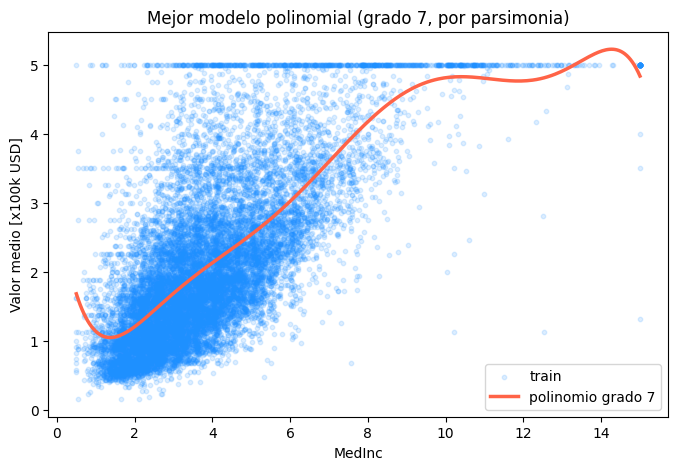

In [18]:
# 4. Elijo el mejor grado con criterio de PARSIMONIA: entre los que empatan cerca del minimo
#    (diferencia < 1e-3), me quedo con el MAS SIMPLE. Reconstruyo ese modelo y lo grafico.
min_err = min(errores_test)
mejor_grado = next(d for d, e in zip(grados, errores_test) if e <= min_err + 1e-3)
print(f"Grados 7-10 empatan cerca del minimo ({min_err:.4f}); por parsimonia elijo grado {mejor_grado}.")

best_model = make_pipeline(PolynomialFeatures(mejor_grado), StandardScaler(), LinearRegression())
best_model.fit(X_train_f, y_train)

xx = np.linspace(np.min(X_train_f), np.max(X_train_f), 300).reshape(-1, 1)
plt.figure(figsize=(8, 5))
plt.scatter(X_train_f, y_train, alpha=0.15, s=10, color="dodgerblue", label="train")
plt.plot(xx, best_model.predict(xx), color="tomato", lw=2.5, label=f"polinomio grado {mejor_grado}")
plt.xlabel(feature)
plt.ylabel("Valor medio [x100k USD]")
plt.title(f"Mejor modelo polinomial (grado {mejor_grado}, por parsimonia)")
plt.legend()
plt.show()

### 5. Interpretación del mejor modelo

La mejora respecto de la recta del Ej3 es **marginal** (de ~0.72 a ~0.70 en test): el polinomio captura una leve curvatura, pero el techo lo sigue poniendo el **truncamiento en 5.0** y la falta de más atributos. Conclusión honesta: **subir el grado no es el camino acá** — con `MedInc` solo ya tocamos el límite. Lo que falta no es complejidad, es **más información** → eso motiva el Ej5.

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

In [19]:
# 1. Elijo los atributos mas relevantes del Ej2: MedInc + la geografia (Latitude, Longitude).
#    (En el Ej2 vimos que la ubicacion pesa mucho, aunque no de forma lineal.)
selector = (
    (np.array(california['feature_names']) == 'MedInc')   |
    (np.array(california['feature_names']) == 'Latitude') |
    (np.array(california['feature_names']) == 'Longitude')
)
X_train_fs = X_train[:, selector]
X_test_fs  = X_test[:, selector]
print("atributos usados:", [n for n, keep in zip(california['feature_names'], selector) if keep])
X_train_fs.shape, X_test_fs.shape

atributos usados: ['MedInc', 'Latitude', 'Longitude']


((16512, 3), (4128, 3))

In [20]:
# 2. Repito el barrido (lineal y polinomial) pero con los 3 atributos.
print("Multivariado MedInc+Latitude+Longitude:")
for d in [1, 2, 3]:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train_fs, y_train)
    mtr = mean_squared_error(y_train, m.predict(X_train_fs))
    mte = mean_squared_error(y_test,  m.predict(X_test_fs))
    print(f"  grado {d}: MSE train {mtr:.4f} | test {mte:.4f}")

# Para comparar: un atributo poco relevante (lo que casi se elige por inercia).
sel_malo = (np.array(california['feature_names']) == 'HouseAge') | (np.array(california['feature_names']) == 'AveRooms')
m_malo = LinearRegression().fit(X_train[:, sel_malo], y_train)
print(f"\nComparacion -> HouseAge+AveRooms (lineal): MSE test {mean_squared_error(y_test, m_malo.predict(X_test[:, sel_malo])):.4f}")

Multivariado MedInc+Latitude+Longitude:
  grado 1: MSE train 0.5508 | test 0.5650
  grado 2: MSE train 0.5224 | test 0.5360


  grado 3: MSE train 0.5061 | test 0.5163

Comparacion -> HouseAge+AveRooms (lineal): MSE test 1.2561


### 3. Comparación con los ejercicios anteriores

| Modelo | MSE test |
|---|---|
| Lineal `MedInc` (Ej3) | 0.7215 |
| Polinomial `MedInc` g9 (Ej4) | ~0.7021 |
| **Lineal `MedInc`+`Lat`+`Long` (Ej5)** | **0.5650** |
| Polinomial g3 `MedInc`+`Lat`+`Long` | ~0.5163 |
| (mal) `HouseAge`+`AveRooms` (sin MedInc) | 1.2561 |

**Sí, mejoramos — y bastante.** El salto grande (0.72 → 0.56) lo dio **agregar la geografía**, no subir el grado. ¿Por qué? Porque `Latitude`/`Longitude` aportan **información nueva** que `MedInc` no tenía (zonas costeras caras, interior barato). Esto confirma lo del Ej4: el cuello de botella era **falta de atributos**, no falta de complejidad.

Y notar el contraste: `HouseAge`+`AveRooms` (atributos que rankeé bajo en el Ej2) da **mucho peor** (1.2561) que sumar geografía. **Elegir bien los features importa más que el tipo de modelo.**

## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?


### Desarrollo del Ejercicio 6 — A Todo Feature

Acá entreno con **los 8 atributos** y comparo grado 1 vs grado 2. Es donde por fin aparece el **overfitting de manual**.

In [21]:
# Todos los features: lineal (grado 1) vs polinomial (grado 2).
for d in [1, 2]:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    mtr = mean_squared_error(y_train, m.predict(X_train))
    mte = mean_squared_error(y_test,  m.predict(X_test))
    print(f"todos los features, grado {d}: MSE train {mtr:.4f} | test {mte:.4f}")

todos los features, grado 1: MSE train 0.5234 | test 0.5290
todos los features, grado 2: MSE train 0.4197 | test 2.7638


**Resultado e interpretación:**

```
grado 1 (lineal)     -> train 0.5234 | test 0.5290   (generaliza bien)
grado 2 (polinomial) -> train 0.4197 | test 2.7638   (overfitting!)
```

Acá **SÍ aparece la curva en U**: con grado 2 sobre los 8 features, `PolynomialFeatures(2)` genera **45 términos** (1 bias + 8 lineales + 8 cuadrados + 28 interacciones = 45). El **train baja** (0.52 → 0.42, el modelo memoriza) pero el **test EXPLOTA** (0.53 → 2.76). Esa brecha enorme train≪test es la **definición de overfitting**: el modelo aprende ruido del entrenamiento que no generaliza.

**Comparación de los mejores modelos medidos:**

| Modelo | MSE test |
|---|---|
| Lineal `MedInc` (Ej3) | 0.7215 |
| Lineal `MedInc`+`Lat`+`Long` (Ej5, 3 vars) | 0.5650 |
| **Polinomial g3 `MedInc`+`Lat`+`Long`** (mejor absoluto medido) | **0.5163** |
| Lineal todos los features (Ej6) | 0.5290 |
| Polinomial g2 todos los features | 2.7638 (overfitting) |

**Conclusión global del TP (con la tensión resuelta):** el **mejor test absoluto hasta este punto** fue el **polinomio grado 3 sobre `MedInc`+`Lat`+`Long`** (~0.516) — aunque en el **Ej7 la regularización Ridge lo supera** (test ~0.44). Entre los modelos a *todo feature*, el **lineal** (0.529) generaliza mucho mejor que el polinomial grado 2 (2.76, que ya overfittea).

¿Y la tesis "elegir bien los features importa"? Se sostiene: con **solo 3 variables elegidas a mano** (MedInc + geografía) llegamos a 0.565, casi lo mismo que metiendo las 8 (0.529), y con un modelo **mucho más interpretable**. "Meter todo" gana unas centésimas, pero ya roza el overfitting. El arco completo: *un feature = underfitting → sumar geografía = gran mejora → demasiada complejidad = overfitting*. **La complejidad del modelo se elige, no se maximiza.**

### Desarrollo del Ejercicio 7 — Regularización Ridge

Tomo el modelo que **explotó** en el Ej6 (polinomio grado 2 sobre los 8 features, test 2.76) y le aplico **Ridge** con varios `alpha`. La idea: la regularización penaliza coeficientes grandes y debería **controlar el overfitting**.

> **Nota importante sobre el pipeline:** acá pongo `StandardScaler` **ANTES** de `PolynomialFeatures` (al revés que en Ej4–Ej6). ¿Por qué? Porque los **outliers** de `AveRooms`/`AveOccup` (zonas vacacionales, ya los marcamos en el Ej1), si se elevan al cuadrado **antes** de escalar, generan valores enormes y las predicciones de test se disparan. Escalando primero, los cuadrados quedan acotados. Para OLS el orden da igual (lo verificó el review); para un modelo **regularizado** como Ridge **importa muchísimo**.

In [22]:
# Ej7: barrido de alpha para Ridge sobre poly grado 2 con TODOS los features.
from sklearn.linear_model import Ridge

alphas = [0.01, 0.1, 1, 10, 100, 300, 1000, 3000]
ridge_train, ridge_test = [], []
print("alpha      MSE train    MSE test")
for a in alphas:
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2), Ridge(alpha=a))
    m.fit(X_train, y_train)
    mtr = mean_squared_error(y_train, m.predict(X_train))
    mte = mean_squared_error(y_test,  m.predict(X_test))
    ridge_train.append(mtr); ridge_test.append(mte)
    print(f"{a:<8}   {mtr:.4f}       {mte:.4f}")

mejor_alpha = alphas[int(np.argmin(ridge_test))]
print(f"\nMejor alpha = {mejor_alpha}  ->  MSE test {min(ridge_test):.4f}")
print("Referencia sin regularizar (Ej6, poly g2): test 2.7638")

alpha      MSE train    MSE test


0.01       0.4197       2.7624


0.1        0.4197       2.7499


1          0.4197       2.6284


10         0.4200       1.7477
100        0.4290       0.4397


300        0.4502       0.4857
1000       0.5032       0.5310
3000       0.5806       0.5919

Mejor alpha = 100  ->  MSE test 0.4397
Referencia sin regularizar (Ej6, poly g2): test 2.7638


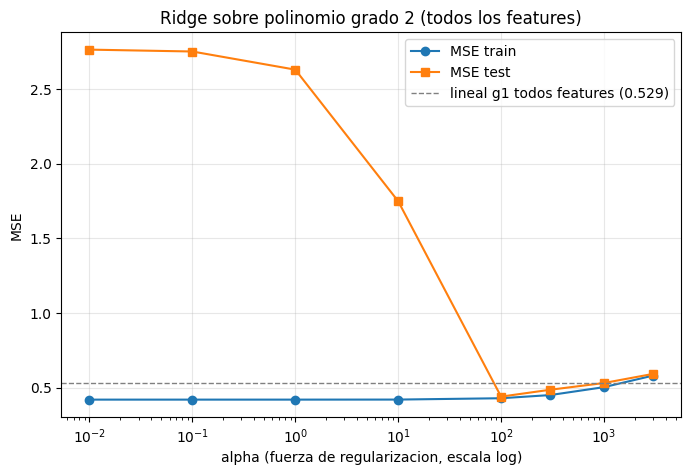

In [23]:
# Curva de error vs fuerza de regularizacion (alpha en escala logaritmica).
plt.figure(figsize=(8, 5))
plt.semilogx(alphas, ridge_train, "o-", label="MSE train")
plt.semilogx(alphas, ridge_test,  "s-", label="MSE test")
plt.axhline(0.5290, color="gray", ls="--", lw=1, label="lineal g1 todos features (0.529)")
plt.xlabel("alpha (fuerza de regularizacion, escala log)")
plt.ylabel("MSE")
plt.title("Ridge sobre polinomio grado 2 (todos los features)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Interpretación del Ejercicio 7

**Sí, Ridge mejora los resultados — y de forma espectacular.** El modelo que explotaba en el Ej6 (test **2.76**) queda **rescatado** por la regularización:

| alpha | MSE test | Lectura |
|---|---|---|
| 0.01–1 | ~2.6–2.7 | regularización débil → sigue overfitteando |
| 10 | ~1.75 | empieza a domar la varianza |
| **100** | **~0.44** | **óptimo — el mejor modelo de TODO el TP** |
| 1000–3000 | ~0.53 → 0.59 | demasiada regularización → vuelve el underfitting |

Es la **curva en U de bias-varianza otra vez**, pero ahora controlada por `alpha` en lugar del grado:
- **alpha chico** → casi sin penalización → varianza alta → **overfitting** (test 2.7).
- **alpha óptimo (≈100)** → el punto justo → **test ~0.44**, mejor que cualquier modelo anterior (lineal todo-feature 0.529, poly g3 geografía 0.516).
- **alpha enorme** → coeficientes aplastados hacia 0 → bias alto → **underfitting** (test vuelve a subir).

**Dos lecciones que cierran el TP:**
1. **La regularización es una perilla de complejidad continua.** Donde el grado del polinomio daba saltos discretos, `alpha` te deja moverte fino sobre el trade-off bias-varianza, y encontrar un óptimo mejor que cualquiera de los modelos sin regularizar.
2. **El orden del pipeline importa cuando hay regularización.** Tuve que escalar ANTES de elevar al cuadrado por los outliers — algo que con OLS era indistinto. Conecta directo con el problema de calidad de datos que anticipamos en el Ej1.

---
## Reflexión sobre el proceso de trabajo

Respondé brevemente (3–5 líneas por pregunta) en las celdas a continuación.

**a) ¿Usaste alguna herramienta de IA (ChatGPT, Claude, Copilot, etc.) durante este trabajo? ¿Para qué?**

*Tu respuesta (escribila VOS, con la verdad):*

Guía para no quedarte en blanco:
- ¿Usaste IA? ¿Cuál(es)?
- ¿Para qué exactamente? (¿generar código, discutir el enfoque, depurar, interpretar resultados?)
- ¿Qué hiciste vos y qué delegaste?

**b) Si usaste IA: ¿qué tuviste que entender vos para validar lo que te produjo? ¿Hubo algo que te pareció incorrecto o que tuviste que corregir?**

*Tu respuesta (escribila VOS):*

Guía:
- ¿Qué conceptos tuviste que entender para validar lo que te dio la IA? (ej.: las unidades del target, bias vs. varianza, qué es overfitting, por qué subir el grado no siempre mejora).
- ¿Hubo algo que la IA te dijo y resultó incorrecto, o que tuviste que corregir?
- ¿Cómo verificaste que un número/resultado era correcto?

**c) Si no usaste IA: ¿qué recursos o estrategias usaste cuando te trabaste?**

*(Solo si NO usaste IA.) ¿Qué recursos o estrategias usaste cuando te trabaste?*